# JAX-GCM (JCM) Demo 

<img src="../logo.png" alt="JAX-GCM Logo" width="200"/>

This notebook demonstrates the capabilities of JAX-GCM (JCM), a differentiable general circulation model built using JAX. 

We will showcase how to set up a simple atmospheric simulation, run the model, and visualize the results. Additionally, we will illustrate how to compute gradients with respect to model parameters using JAX's automatic differentiation features.



In [8]:
from jcm.physics.icon import IconPhysics
from jcm.model import Model

physics = IconPhysics()

model = Model(
    physics=physics,
)

init_state = model._prepare_initial_modal_state(humidity_perturbation=True)

predictions = model.run(
    save_interval=1/48,  # Save every 30 minutes
    total_time=1/12,    # Total simulation time of 2 hours
    output_averages=False,
    initial_state=init_state,
)


In [9]:
# create non-hybrid coords
from dinosaur.coordinate_systems import CoordinateSystem
_coords = CoordinateSystem(model.coords.horizontal, model.coords.vertical.to_approx_sigma_coords(40))
pred_ds = predictions.to_xarray(physics, coords=_coords)
pred_ds

Skipping single time dimension array: date.tyear with shape (1, 4)
Skipping single time dimension array: date.dt._delta._days with shape (1, 4)
Skipping single time dimension array: date.dt._delta._seconds with shape (1, 4)
Skipping single time dimension array: date.model_year with shape (1, 4)
Skipping single time dimension array: date.model_step with shape (1, 4)
Skipping single time dimension array: date.dt_seconds with shape (1, 4)
Skipping interface-level data: diagnostics.pressure_half with shape (4, 41, 96, 48)
Skipping interface-level data: diagnostics.height_half with shape (4, 41, 96, 48)
Skipping interface-level multi-channel array: radiation.sw_flux_up with shape (4, 41, 96, 48, 10)
Skipping interface-level multi-channel array: radiation.sw_flux_down with shape (4, 41, 96, 48, 10)
Skipping interface-level multi-channel array: radiation.lw_flux_up with shape (4, 41, 96, 48, 10)
Skipping interface-level multi-channel array: radiation.lw_flux_down with shape (4, 41, 96, 48, 10

<xarray.Dataset> Size: 103MB
Dimensions:                                  (time: 4, level: 40, lon: 96,
                                              lat: 48)
Coordinates:
  * lon                                      (lon) float64 768B 0.0 ... 356.2
  * lat                                      (lat) float64 384B -87.16 ... 87.16
  * level                                    (level) float32 160B 0.9956 ... ...
  * time                                     (time) datetime64[ns] 32B 2000-0...
Data variables: (12/70)
    aerosol.ssa_profile                      (time, level, lon, lat) float32 3MB ...
    radiation.lw_heating_rate                (time, level, lon, lat) float32 3MB ...
    surface.cm                               (time, lon, lat) float32 74kB ...
    surface.evaporation                      (time, lon, lat) float32 74kB ...
    radiation.surface_sw_down                (time, lon, lat) float32 74kB ...
    radiation.surface_albedo_vis             (time, lon, lat) float32 74kB ...
    ...                                       ...
    surface.momentum_flux_u                  (time, lon, lat) float32 74kB ...
    chemistry.methane_loss                   (time, level, lon, lat) float32 3MB ...
    chemistry.ozone_production               (time, level, lon, lat) float32 3MB ...
    clouds.precip_rain                       (time, lon, lat) float32 74kB ...
    chemistry.ozone_dry_deposition           (time, lon, lat) float32 74kB ...
    vertical_diffusion.tke                   (time, level, lon, lat) float32 3MB ...

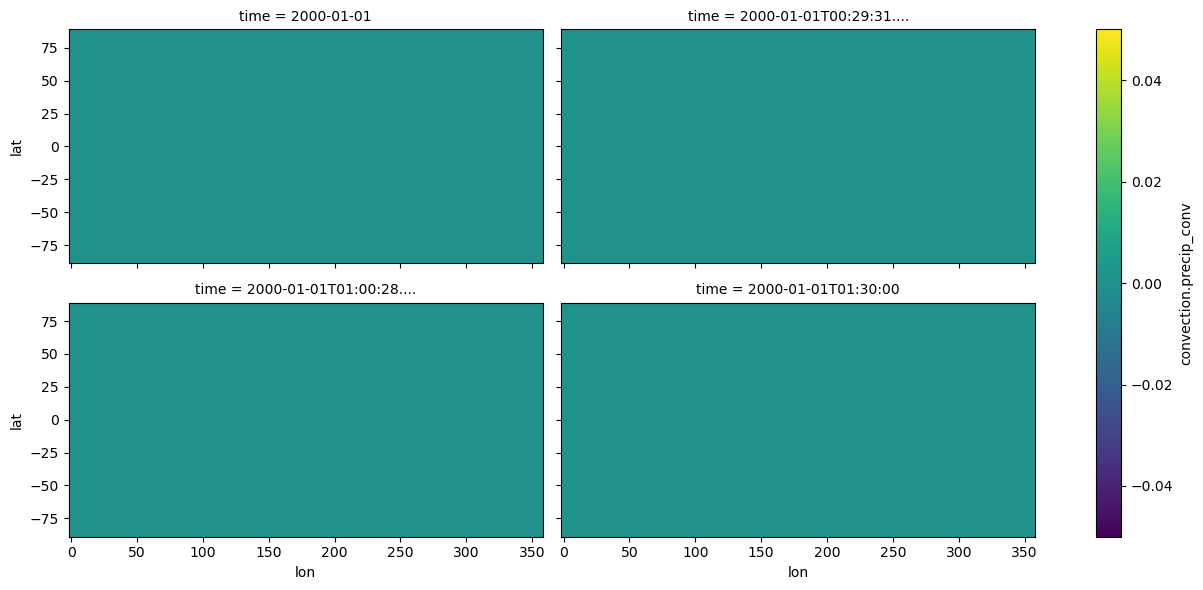

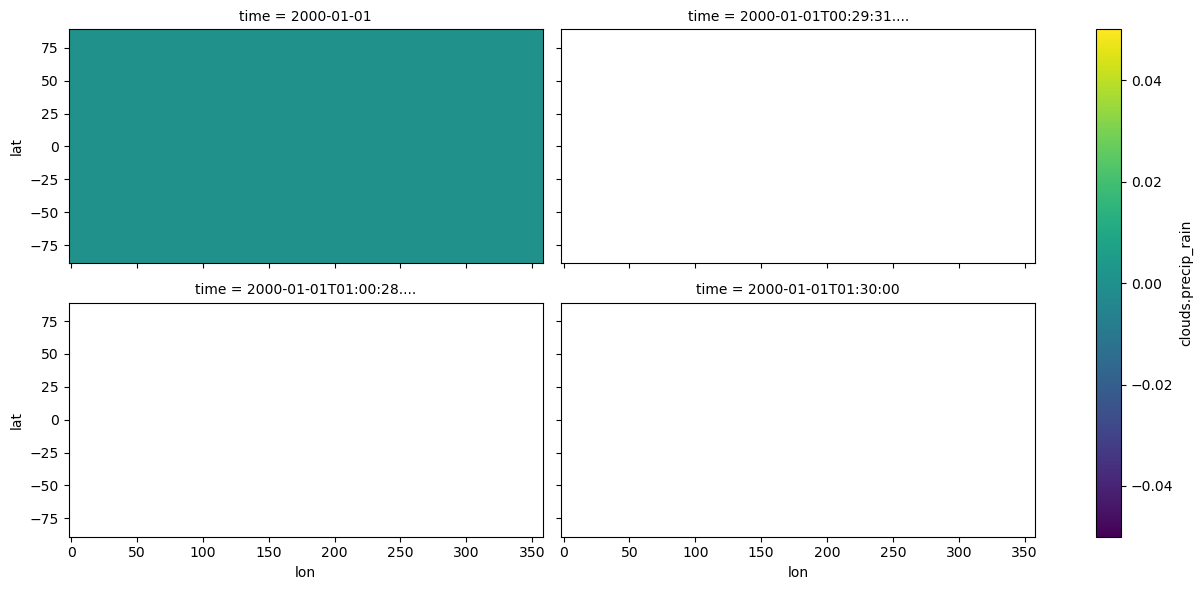

In [10]:
pred_ds['convection.precip_conv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
pred_ds['clouds.precip_rain'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

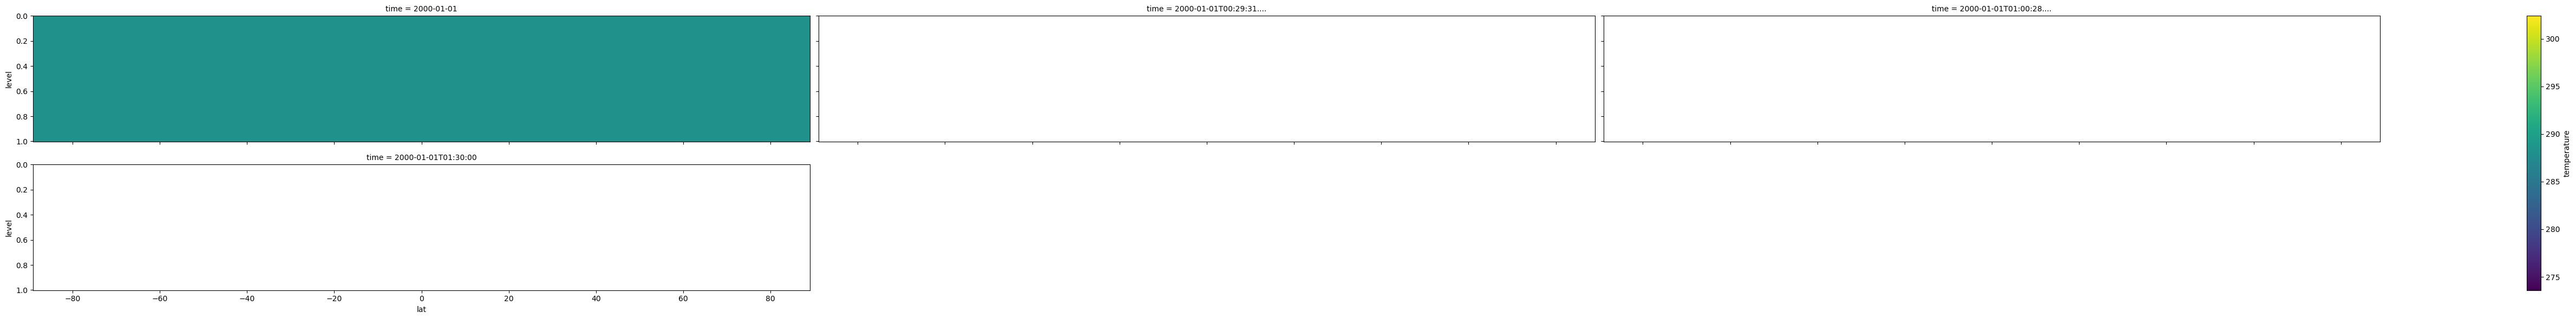

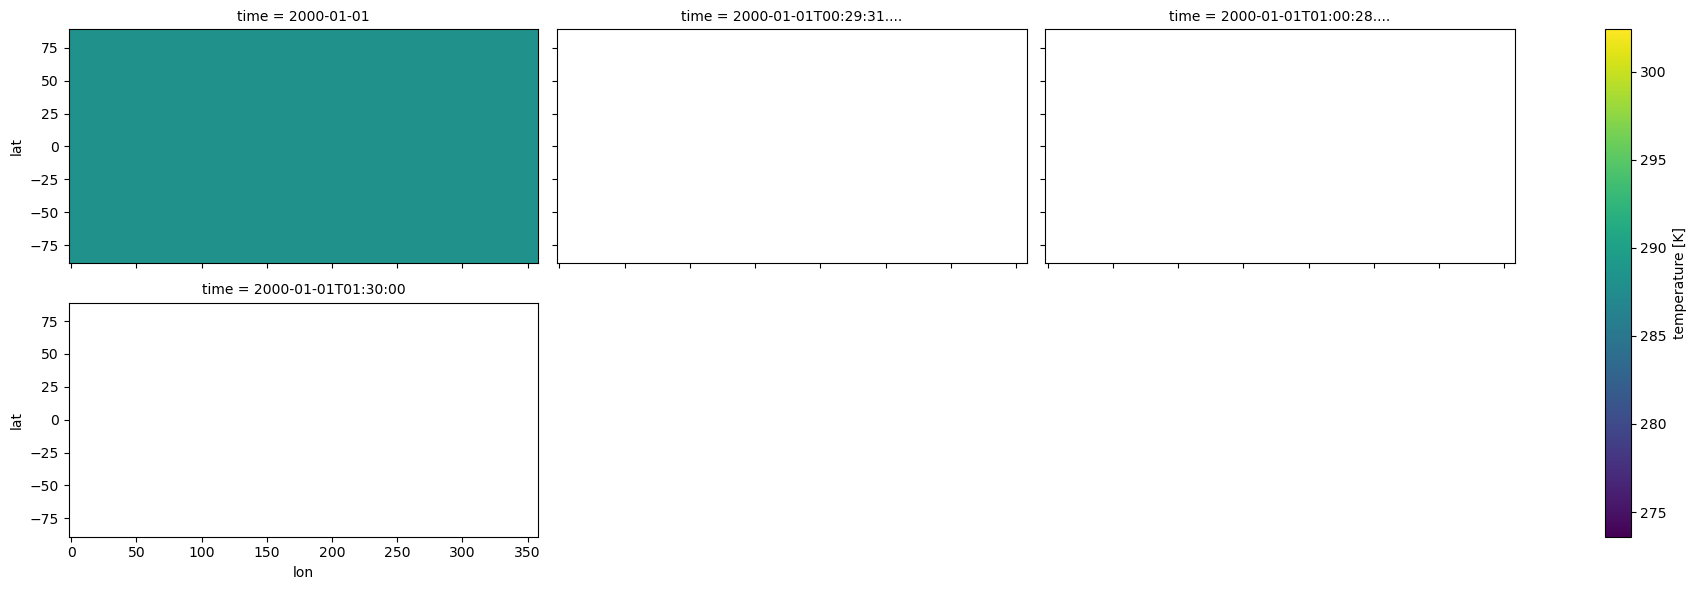

In [11]:
pred_ds['temperature'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['temperature'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

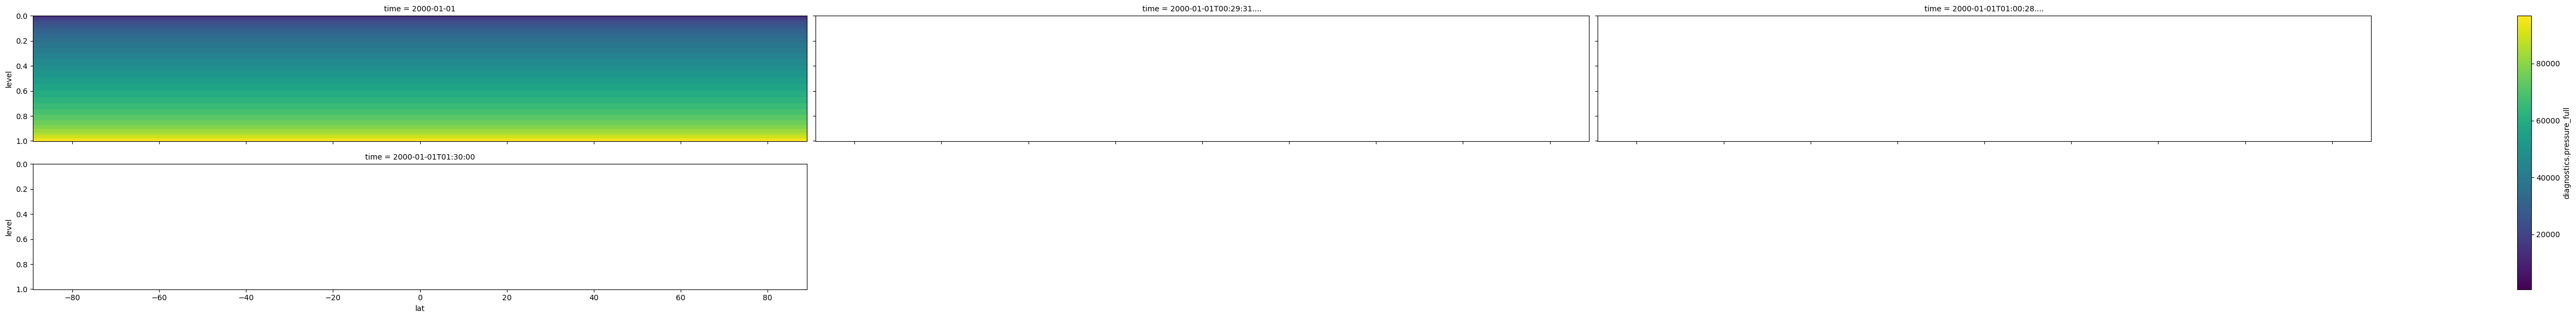

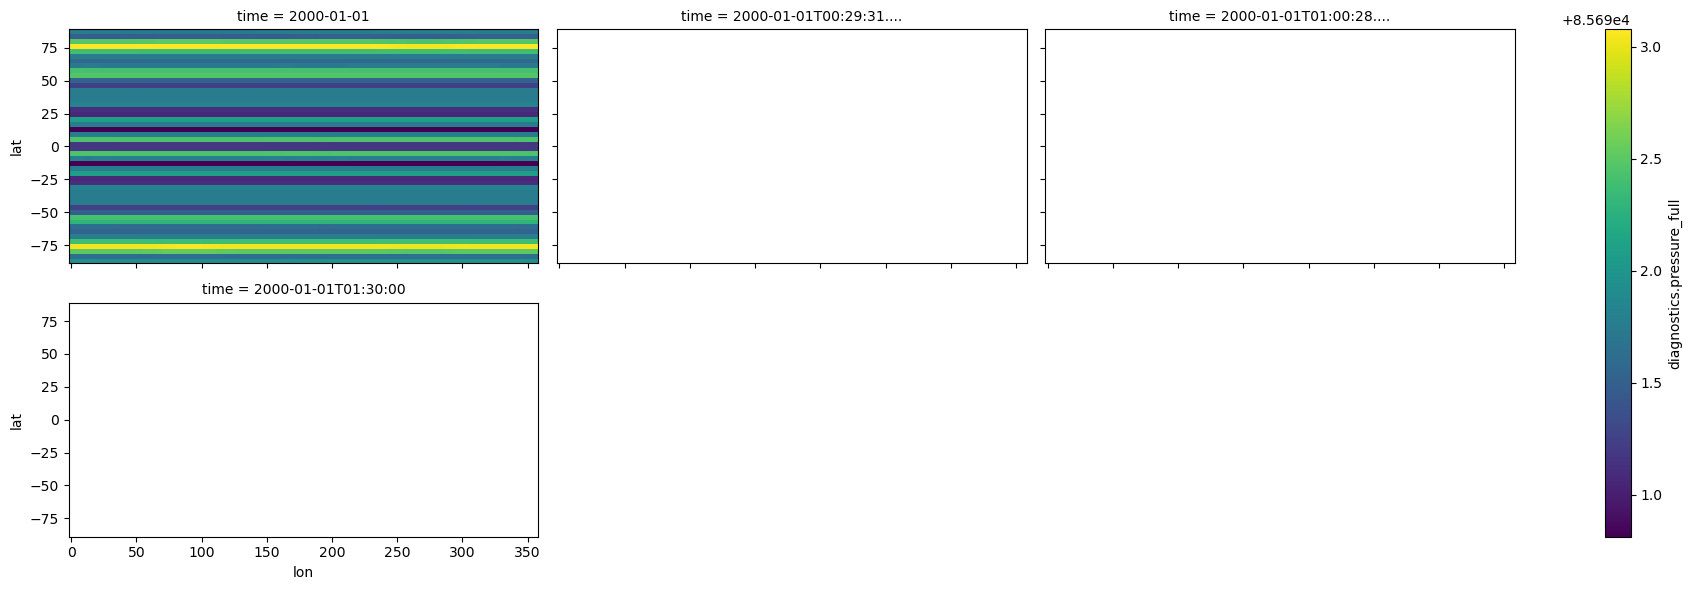

In [12]:
pred_ds['diagnostics.pressure_full'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['diagnostics.pressure_full'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

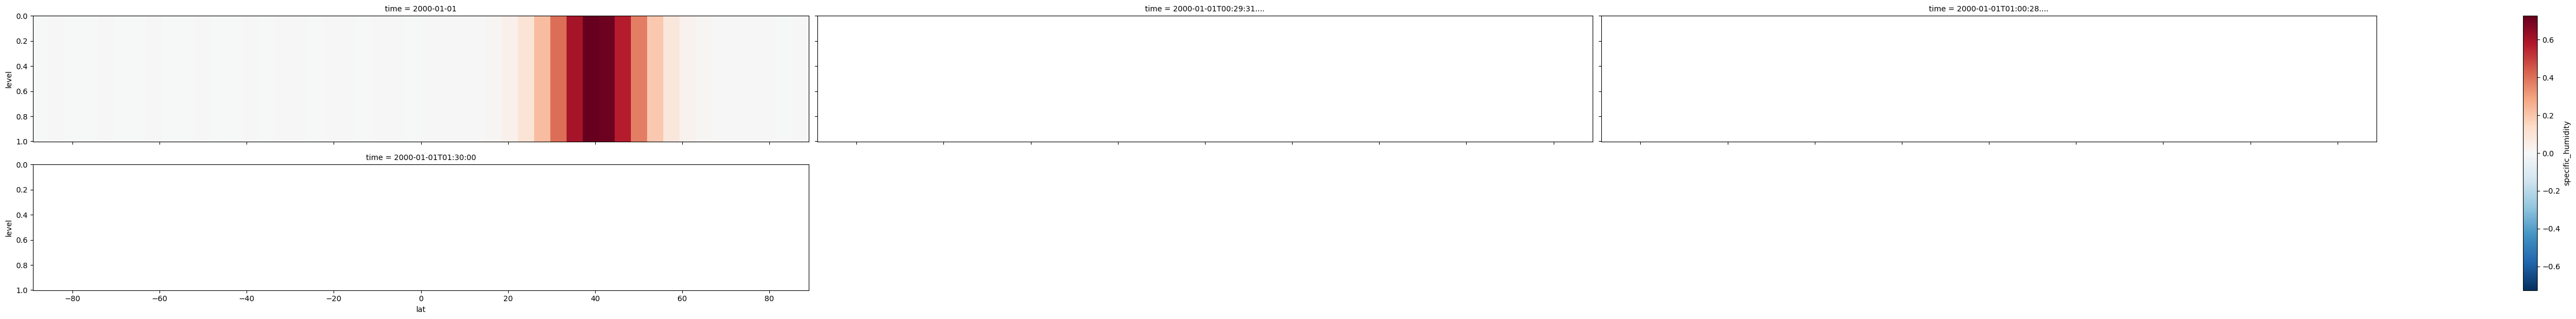

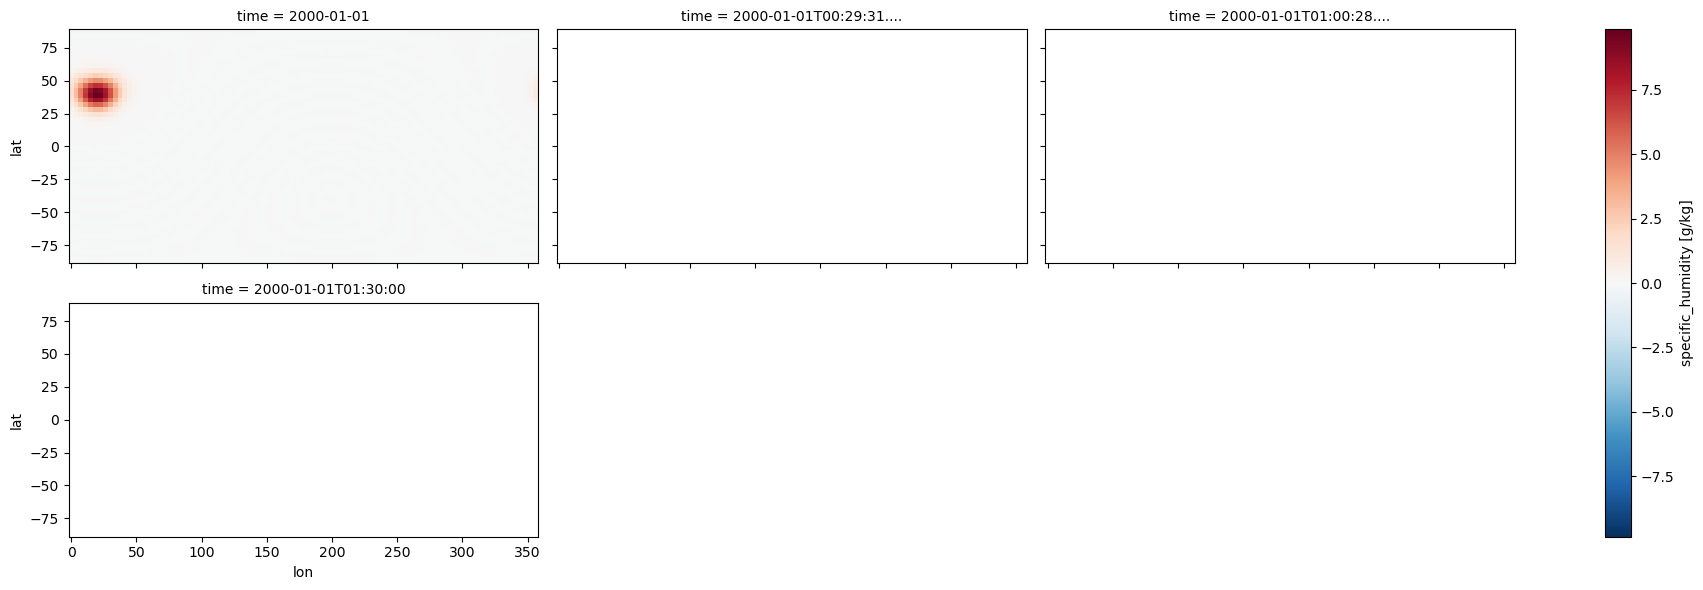

In [13]:
pred_ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

### Clouds!

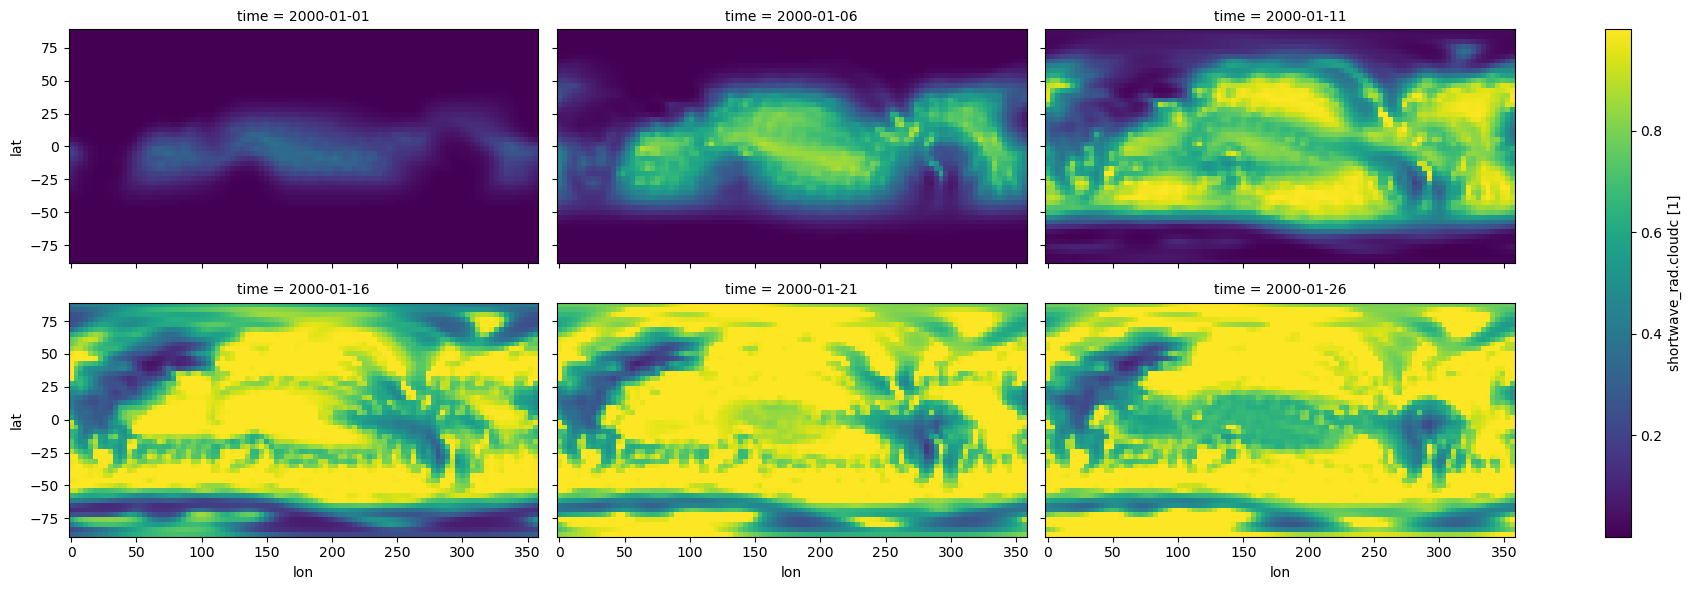

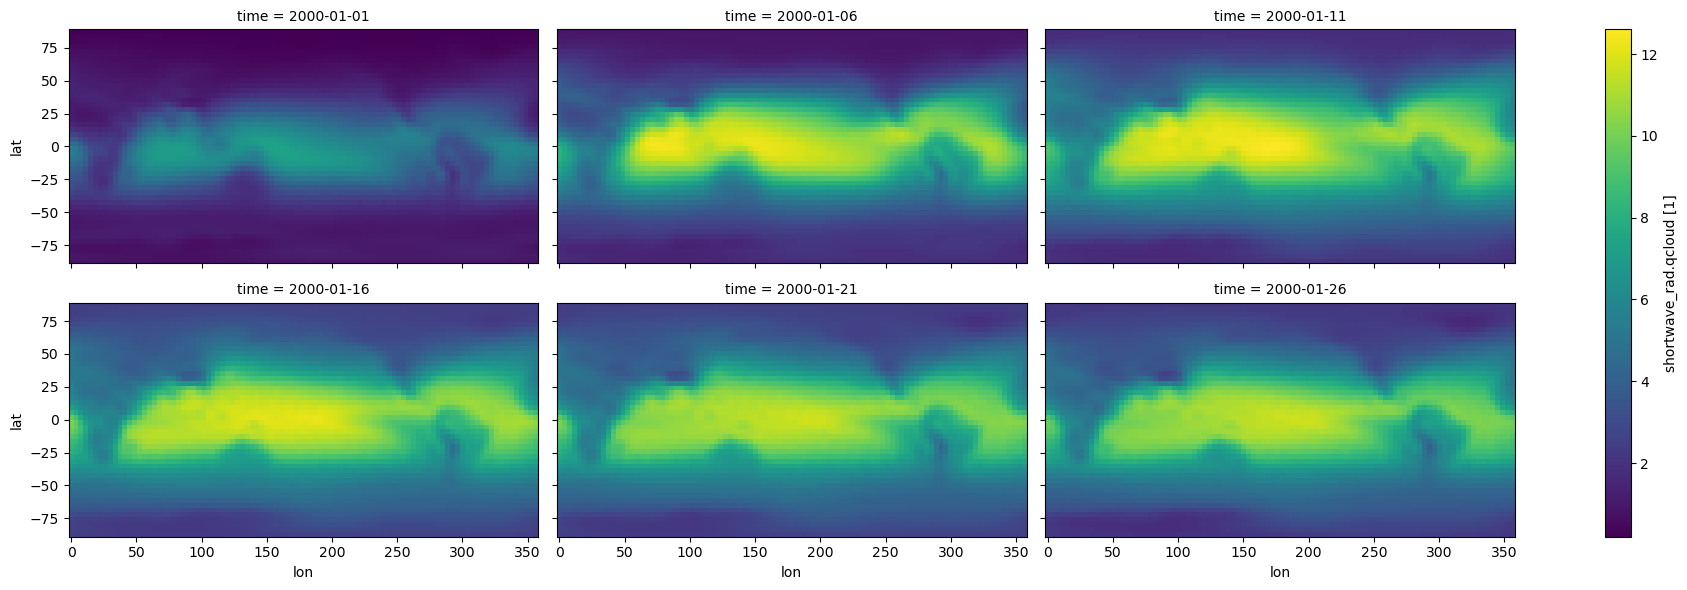

In [ ]:
pred_ds['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
pred_ds['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

## Continue running

Continue a simulation from the previous state for an additional 30 days, saving every 5 days and outputting averages.


In [ ]:
predictions = model.resume(
    total_time=30,
    output_averages=True,
    forcing=realistic_forcing,
)

Sometimes, for example in a coupled run we want a pure JAX interface to enable compilation of a larger model. We can do this using the `run_from_state` method:

```python
model.run_from_state(
    initial_state=model._final_modal_state,
    total_time=30,
    output_averages=True,
    forcing=realistic_forcing,
)
```

## Note on speed and efficiency

Some preliminary tests show very good performance on a variety of devices but especially on GPUs and TPUs. For example, on a V100 GPU we see around 10x speedup compared to a CPU run. JCM also supports parallelization across multiple devices using JAX's `pmap` functionality, which can further enhance performance for large-scale simulations.

<center><img src="jcm_scaling.png" alt="JCM Performance" width="400"/></center>

## Model Gradients

We can compute gradients of model outputs with respect to model parameters using JAX's automatic differentiation. 

In [ ]:
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
from jcm.physics.speedy.speedy_physics import SpeedyPhysics
from jcm.physics.speedy.params import Parameters

# Key step - create a function that makes a model given parameters
def model_run_wrapper(params):
    model = Model(geometry=realistic_geometry, physics=SpeedyPhysics(parameters=params))

    return model.run(save_interval=1, total_time=1, forcing=realistic_forcing, output_averages=True)

In [ ]:
# VJP is the vector-Jacobian product and calculates the gradient of outputs with respect to inputs

primal, vjp_fn = jax.vjp(model_run_wrapper, Parameters.default())

In [ ]:
def create_cotangent(primal):
    cotangent = jtu.tree_map(jnp.zeros_like, primal)
    cotangent.physics.shortwave_rad.ftop = jtu.tree_map(jnp.ones_like, cotangent.physics.shortwave_rad.ftop)
    return cotangent

grad, = vjp_fn(create_cotangent(primal))

In [ ]:
print(grad)

Parameters(convection=ConvectionParameters(psmin=0.0,
                                           trcnv=0.0,
                                           rhil=0.0,
                                           rhbl=0.0,
                                           entmax=0.0,
                                           smf=0.0),
           condensation=CondensationParameters(trlsc=0.0,
                                               rhlsc=0.0,
                                               drhlsc=0.0,
                                               rhblsc=0.0),
           shortwave_radiation=ShortwaveRadiationParameters(albcl=-0.034563131630420685,
                                                            albcls=-502230.5625,
                                                            absdry=1004539.0625,
                                                            absaer=297534.34375,
                                                            abswv1=159370.4375,
                               

We can also calculate the Jacobian-vector product (JVP) to get gradients of specific outputs with respect to a parameter

In [ ]:
# Define a tangent vector for JVP
params = Parameters.default()
tangent = Parameters.zeros()
tangent.mod_radcon.albsea = jnp.array(1.)

y, jvp_at_x = jax.jvp(model_run_wrapper, (params,), (tangent,))

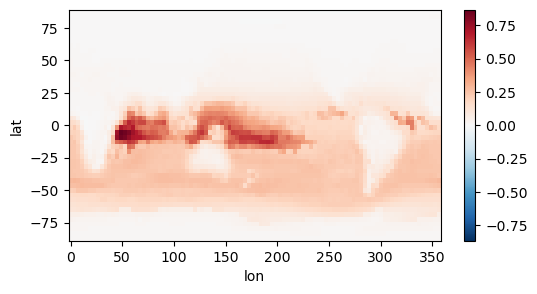

In [ ]:
import xarray as xr
xr.DataArray(jvp_at_x.physics.surface_flux.hfluxn[0, :, :, 0], dims=['lon', 'lat'],
                coords={'lat': pred_ds.lat, 'lon': pred_ds.lon}).plot(x='lon', y='lat', size=3, aspect=2)

## Advanced

Sometimes it can be useful to control the compilation or execution of the JAX code more directly. JAX has configuration functions to facilitate this.

In [ ]:
print("JAX device:", jax.devices())

# import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"  # for use on ARM Macs

jax.config.update('jax_disable_jit', False) # disable if necessary for debugging
jax.config.update("jax_debug_infs", True) # watch for model blowup
jax.config.update("jax_debug_nans", False) # some physics fields might be nan